In [3]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt 

In [72]:
########## Problem 1

# task 1

# The boundary conditions given in this problem are that psi(0) = psi(1) = 0, and both 0(1-0)0^j and 1(1-1)1^j are equal to 0, satisfying the boundary conditions. A regular eigenvalue problem of the form Hc = Ec can be found from the generalized version of Hc = ESc,
# where S is the overlap. If the basis is orthogonal, then <b_i|b_j> would be the identity matrix and drops out of the problem. We are given that the basis is not orthogonal, and so we have this extra S matrix. 

In [73]:
# task 2

def b_j(j, x): 
    return x * (1 - x) * x**j

# The gauss-legendre quadrature says that the integral from -1 to 1 of a function is approximately equal to the sum of a weighting function w_i times a function of x_i where x_i are roots of the the nth legendre polynomial. In the context of this problem, it means
# that instead of doing the integral, we do a 200 point sum with the w_i and x_i. However, the problem limits are from 0 to 1. If you use x' = ax + b with x being -1,1 and x' being 0,1, you get the equations 0 = a(-1) + b and 1 = a(1) + b which can be solved for 
# a = b = 0.5 for the x's. This transformation also halves the weights because dx = 0.5 dx' and we want the integrals to match for the sum to be valid. 

x_i, w_i = np.polynomial.legendre.leggauss(200)

x = 0.5 * x_i + 0.5
w = 0.5 * w_i 

# M is from 0 to 5 so the matrices are from 1x1 to 6x6. I'd like to append the matrix size to the variable name, but google tells me this is not how it works. Instead, I'll just manually make the matrices which wouldn't be valid if M was like 100, but I hope it's
# fine for now. 

S_0 = np.zeros((1, 1))

for i in range(1):
    for j in range(1):
        S_0[i,j] = np.sum(w * b_j(j,x) * b_j(i,x))

S_1 = np.zeros((2, 2))

for i in range(2):
    for j in range(2):
        S_1[i,j] = np.sum(w * b_j(j,x) * b_j(i,x))

S_2 = np.zeros((3, 3))

for i in range(3):
    for j in range(3):
        S_2[i,j] = np.sum(w * b_j(j,x) * b_j(i,x))

S_3 = np.zeros((4, 4))

for i in range(4):
    for j in range(4):
        S_3[i,j] = np.sum(w * b_j(j,x) * b_j(i,x))

S_4 = np.zeros((5, 5))

for i in range(5):
    for j in range(5):
        S_4[i,j] = np.sum(w * b_j(j,x) * b_j(i,x))

S_5 = np.zeros((6, 6))

for i in range(6):
    for j in range(6):
        S_5[i,j] = np.sum(w * b_j(j,x) * b_j(i,x))

# the H matrix basically the same but using the derivative of b_j and also there is an extra half on the front of the integral
        
def db_j(j, x):
    return (j + 1) * x ** j - (j + 2) * x ** (j + 1)

H_0 = np.zeros((1, 1))

for i in range(1):
    for j in range(1):
        H_0[i,j] = 0.5 * np.sum(w * db_j(j,x) * db_j(i,x))

H_1 = np.zeros((2, 2))

for i in range(2):
    for j in range(2):
        H_1[i,j] = 0.5 * np.sum(w * db_j(j,x) * db_j(i,x))

H_2 = np.zeros((3, 3))

for i in range(3):
    for j in range(3):
        H_2[i,j] = 0.5 * np.sum(w * db_j(j,x) * db_j(i,x))

H_3 = np.zeros((4, 4))

for i in range(4):
    for j in range(4):
        H_3[i,j] = 0.5 * np.sum(w * db_j(j,x) * db_j(i,x))

H_4 = np.zeros((5, 5))

for i in range(5):
    for j in range(5):
        H_4[i,j] = 0.5 * np.sum(w * db_j(j,x) * db_j(i,x))

H_5 = np.zeros((6, 6))

for i in range(6):
    for j in range(6):
        H_5[i,j] = 0.5 * np.sum(w * db_j(j,x) * db_j(i,x))

# lastly, we need to solve Hc = ESc, which scipy can do

E_0, c_0 = sp.linalg.eigh(H_0, S_0)
print("M=0, E = ", E_0, ", c = ", c_0)

E_1, c_1 = sp.linalg.eigh(H_1, S_1)
print("M=1, E = ", E_1, ", c = ", c_1)

E_2, c_2 = sp.linalg.eigh(H_2, S_2)
print("M=2, E = ", E_2, ", c = ", c_2)

E_3, c_3 = sp.linalg.eigh(H_3, S_3)
print("M=3, E = ", E_3, ", c = ", c_3)

E_4, c_4 = sp.linalg.eigh(H_4, S_4)
print("M=4, E = ", E_4, ", c = ", c_4)

E_5, c_5 = sp.linalg.eigh(H_5, S_5)
print("M=5, E = ", E_5, ", c = ", c_5)


M=0, E =  [5.] , c =  [[5.47722558]]
M=1, E =  [ 5. 21.] , c =  [[-5.47722558e+00 -1.44913767e+01]
 [ 1.16573418e-14  2.89827535e+01]]
M=2, E =  [ 4.93487481 21.         51.06512519] , c =  [[ 4.40399751e+00 -1.44913767e+01  2.86462005e+01]
 [ 4.99034860e+00  2.89827535e+01 -1.32721876e+02]
 [-4.99034860e+00  5.01347019e-13  1.32721876e+02]]
M=3, E =  [  4.93487481  19.75077641  51.06512519 100.2492236 ] , c =  [[ 4.40399751e+00  8.39117608e+00 -2.86462005e+01 -4.94933143e+01]
 [ 4.99034860e+00  1.91415561e+01  1.32721876e+02  3.85115049e+02]
 [-4.99034860e+00 -1.07771725e+02 -1.32721876e+02 -8.58385260e+02]
 [-3.31164716e-13  7.18478164e+01 -1.04973242e-10  5.72256840e+02]]
M=4, E =  [  4.93480222  19.75077641  44.58681182 100.2492236  175.47838595] , c =  [[ 4.44358795e+00  8.39117608e+00 -1.14920109e+01  4.94933143e+01
   7.84103833e+01]
 [ 4.42384947e+00  1.91415561e+01 -6.78731857e+01 -3.85115049e+02
  -8.94009877e+02]
 [-2.70791349e+00 -1.07771725e+02  6.10354763e+02  8.58385260e

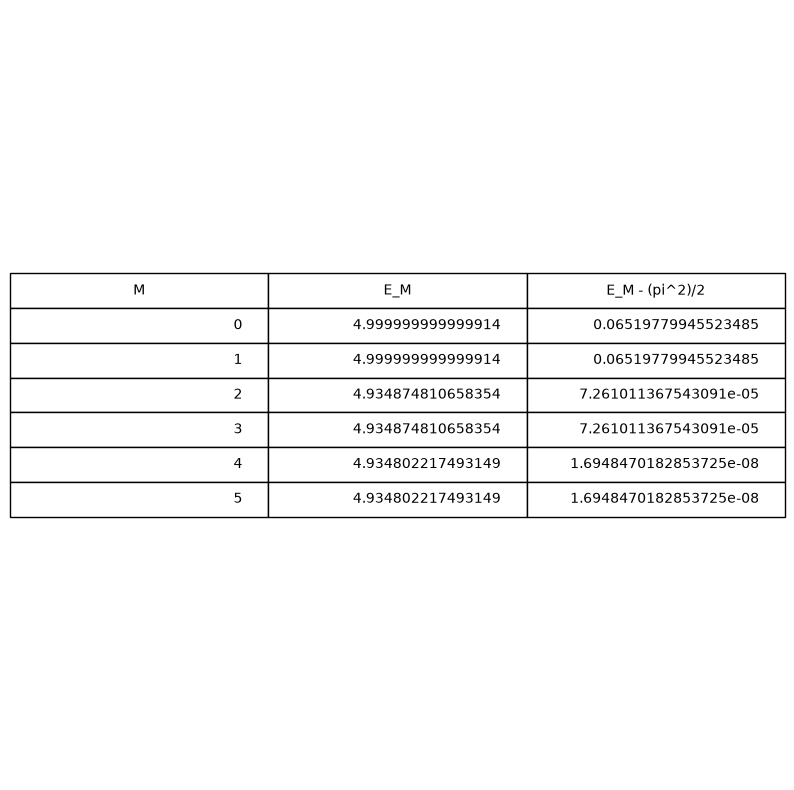

In [74]:
# task 3

energy = [E_0[0], E_1[0], E_2[0], E_3[0], E_4[0], E_5[0]]

table = []

for i in range(len(energy)):
    table.append([i, energy[i], energy[i] - (np.pi**2)/2])

plt.table(cellText = table, colLabels = ["M", "E_M", "E_M - (pi^2)/2"], loc = "center")
plt.axis("off")
plt.gcf().set_size_inches(10,10)
plt.show()

# as seen in the table below, for increasing M, the energy is either equal to or less than the previous energy. This means that it is monotonically nonincreasing. Additionally, from the 3rd column, we can see that the energies - (pi^2)/2 are approaching 0
# from the positive direction, which is to say that we are approaching E_0 = (pi^2)/2 from above. This is expected, as the variational principle says that E[psi] >= E_0. Note that since L, m, and hbar have been given as "1", I have left the energy unitless.

Max absolute difference: 1.4483272868126562e-05


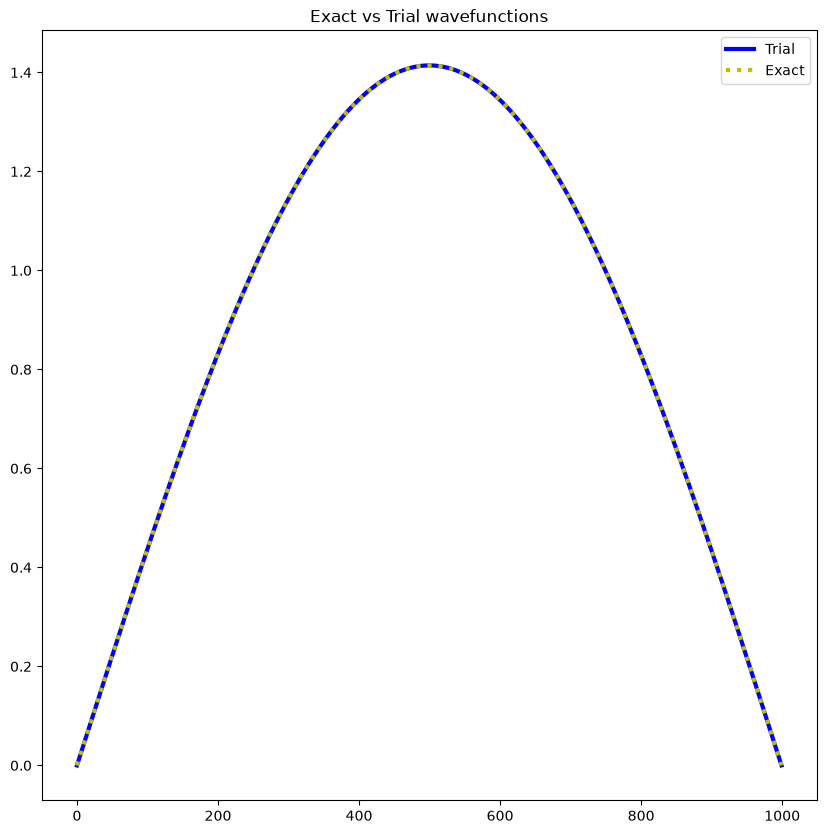

In [75]:
# task 4

# the exact solution is to be plotted against the trial wavefunction for M = 5, so constants are pulled from the c_5 matrix

plot_x = np.linspace(0, 1, 1000)

psi_exact = np.sqrt(2) * np.sin(np.pi * plot_x)

psi_trial = np.zeros_like(plot_x)

for i in range(6): 
    psi_trial += c_5[i, 0] * b_j(i, plot_x)

plt.plot(psi_trial, linestyle = "solid", color = "b", label = "Trial", lw = 3)
plt.plot(psi_exact, linestyle = "dotted", color = "y", label = "Exact", lw = 3)
plt.title("Exact vs Trial wavefunctions")
plt.gcf().set_size_inches(10,10)
plt.legend()

# visually, the wavefunctions look basically the same, but we want to find the maximum absolute difference. We can just check the difference at each x and report the largest.

difference = 0

for i in range(len(plot_x)):
    plot_diff = np.abs(psi_exact[i] - psi_trial[i])
    if plot_diff > difference:
        difference = plot_diff

print("Max absolute difference:", difference)

In [76]:
# task 5

# To be honest, I'm not entirely sure. But if I were to field a guess, it probably has to do with the basis not being orthogonal here. In my head, for something orthogonal like sine and cosine, I imagine that adding more functions will always change the energy because they're,
# well, orthogonal. Since we know this basis is not orthogonal, there is perhaps some inner working in which adding functions sometimes doesn't impact it. From the table, it seems that all odd j do not change the energy. In the textbook's section 2.5.16, there is mention that
# the "best value" remains the upper bound, so maybe something about odd j in this basis prevents it from being an improvement. 

In [77]:
########## Problem 2

# task 1

# we are looking to iterate the x, y, and z directions from -8 to 8 and find the q for each (x,y,z). Then we can collect the total states for each q and their degeneracy.  


all_states = []

for x in range(-8,9):
    for y in range(-8,9):
        for z in range(-8,9):
            q = x**2 + y**2 + z**2
            all_states.append([q,x,y,z])

# now that we have all states, we can collect each unique q. For ease of use, they're also sorted by magnitude afterwards

all_qs = []

for i in range(len(all_states)):
    if all_states[i][0] not in all_qs:
        all_qs.append(all_states[i][0])

all_qs.sort(key = abs)

# now we just count each occurence of any given q and keep track of it as degeneracy

q_degen = np.zeros_like(all_qs)

for i in range(len(all_states)):
    for j in range(len(all_qs)):
       if all_states[i][0] == all_qs[j]:
           q_degen[j] += 1

# lastly, we just list out the 12 lowest q's, their degeneracy, and spin inclusive capacity

print(f"{"q":>10} {"degeneracy":>20} {"spin inclusive capacity":>30}")
for i in range(12):
    print(f"{all_qs[i]:>10} {q_degen[i]:>20} {q_degen[i] * 2:>30}")

         q           degeneracy        spin inclusive capacity
         0                    1                              2
         1                    6                             12
         2                   12                             24
         3                    8                             16
         4                    6                             12
         5                   24                             48
         6                   24                             48
         8                   12                             24
         9                   30                             60
        10                   24                             48
        11                   24                             48
        12                    8                             16


In [78]:
# task 2

# for 54 electrons, it's easy enough to find the highest occupied state by just counting that 2+12+24+16=54 which means that q_f = 3. But it would be nice to automate for any amount of electrons by summing the spin capacities
# of all q's upward. Once we reach the required electrons, the most recent q level is q_f

electrons = 54
e_filling = 0
q_f = 0

for i in range(len(q_degen)):
    e_filling += 2 * q_degen[i]
    if e_filling >= electrons:
        q_f = all_qs[i]
        break

print("q_f = ", q_f)

# to find the wavevector and energy, we just use the given equations 6 and 7 respectively. For the wavevector, since at q_f, they all have the same magnitude, we can just use xyz from the first state with the correct q. The other options are all
# just sign changes anyway. For the energy, we just multiply energy_0 by q_f and then convert to eV when reporting.

cell_length = 1 * 10**(-9)
m_e = 9.1093837139 * 10**(-31)
hbar = 	1.054571817 * 10**(-34)

energy_0 = ((hbar**2)/(2 * m_e)) * ((2 * np.pi)/cell_length)**2

joule_to_ev = 1.602176634 * 10**(-19)

for i in range(len(all_states)):
    if all_states[i][0] == q_f:
        fermi_direction = [all_states[i][1], all_states[i][2], all_states[i][3]]
        break

fermi_wavevector = str((2 * np.pi)/cell_length) + str(fermi_direction)
fermi_energy = energy_0 * q_f

print("fermi_wavevector:",fermi_wavevector, "m^(-1)")
print("fermi energy:", fermi_energy/joule_to_ev, "eV")

q_f =  3
fermi_wavevector: 6283185307.179585[-1, -1, -1] m^(-1)
fermi energy: 4.512361939728847 eV


In [79]:
# task 3

# we already have N and L in the last cell, so we can make the density easily here. From there, we just plug into the given equations

n_density = electrons / cell_length**3

k_f = (3 * np.pi**2 * n_density)**(1/3)
E_f = ((hbar**2)/(2 * m_e)) * k_f**2

# the percent difference between the continuum and finite cell is also pretty straight forward

percent_diff = 100 * (np.abs(E_f - fermi_energy))/fermi_energy

print("percent difference between continuum and cell energy:", percent_diff)

# there is ~15.5 percent difference between these estimates. The reason there is a difference between these is that the discrete and continuum estimates have slightly different radii to their fermi sphere. The more electrons there are, the closer
# these estimates will get because the individual cell size will matter less overall. 

percent difference between continuum and cell energy: 15.450419467737673


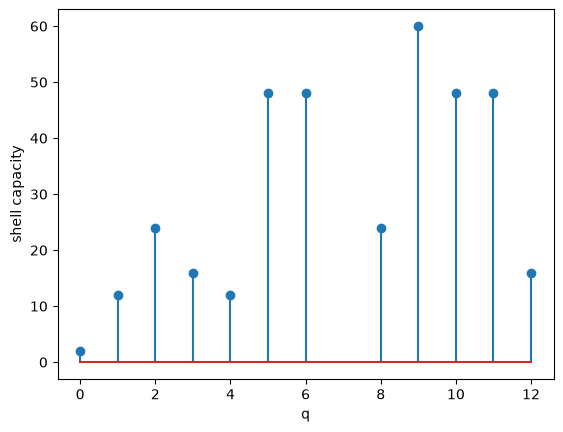

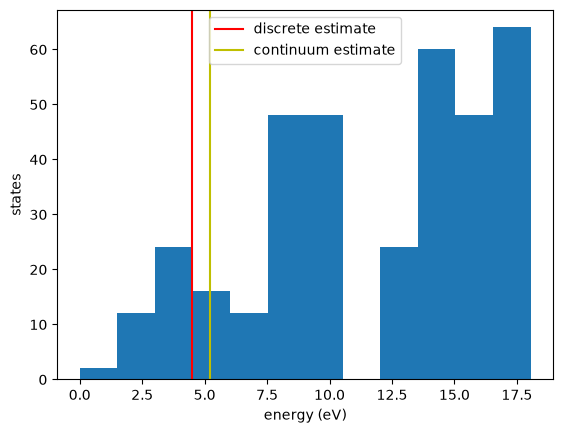

In [80]:
# task 4

# this part reads a bit ambiguously to me, does the stem plot need all q vs capacity or just 12 like the histogram? I think 12 makes more sense, but in any case, we can just use the first 12 elements of the q list and q degeneracy list

plt.stem(all_qs[0:12], q_degen[0:12] * 2)
plt.xlabel("q")
plt.ylabel("shell capacity")
 
# for the histogram, we want the energy for each of the first 12 shells. To factor in shell capacity, we can just place said energy into the array multiple times based on degeneracy * 2 for spin. Since we're looking at 12 shells, I made 12 bins.
# This also means that when marking the discrete and continuum estimates on the histogram, the discrete estimate will line up exactly with one of the bins and the continuum estimate will be somewhere between bins.

histogram_energy = []

for i in range(12):
    for j in range(2 * q_degen[i]):
        histogram_energy.append(energy_0 * all_qs[i] / joule_to_ev)

plt.figure()
plt.hist(histogram_energy, bins = 12)
plt.xlabel("energy (eV)")
plt.ylabel("states")
plt.axvline(fermi_energy/joule_to_ev, label = "discrete estimate", color = "r")
plt.axvline(E_f/joule_to_ev, label = "continuum estimate", color = "y")
plt.legend()


In [81]:
# task 5 

# When counting states, the orbital degeneracy is counted first and spin is counted second. The +k and -k distinction is already built into the orbital degeneracy. For the state q = 1, you have (1,0,0), (0,1,0), (0,0,1), (-1,0,0), 
# (0,-1,0), and (0,0,-1). The orbital degeneracy here is 6, and the first 3 correspond to +k and second 3 correspond to -k. Then we multiply by 2 for spin since we have a spin up and down state for each k. The k distinction is what
# we are explicitly trying to avoid double counting. 


In [82]:
########## Problem 3

# task 1

# For equation 11, there are a couple of concerns. If x = 0 or 1, then we get division by 0 and if x = -1, then we get log(0). We are given that F(0) = 2 and F(1) = 1 explicitly, which solve the division by 0 problems. The log(0)
# issue is a bit more awkward, but there is 1-x^2 which will be a 0 at x = -1. Since this is 0 times infinity, this is an indeterminate form. That said, wolfram alpha tells me that the limit will end up being 1, so this function 
# can just be defined with a handful of exceptions. 

def F(x):
    if x == 0:
        return 2
    if x == 1:
        return 1
    if x == -1: 
        return 1
    else: 
        return 1 + (1 - x**2)/(2 * x) * np.log(abs((1 + x)/(1 - x)))

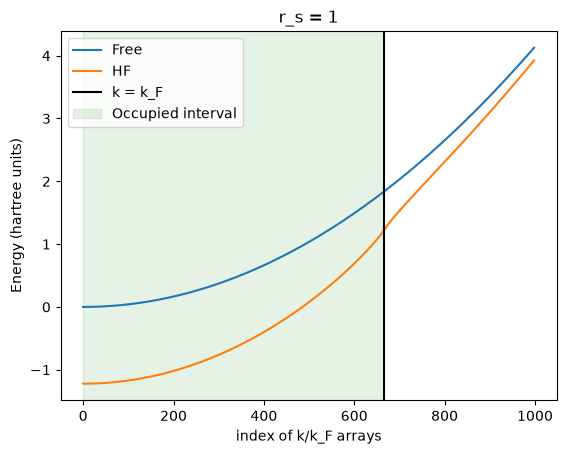

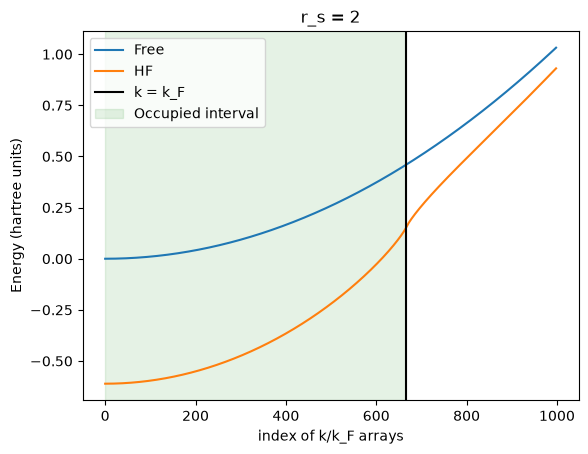

In [83]:
# task 2

# for this plot, I need equation 13 for r_s = 1 and 2. I'll swap out k for x * kF and then plot in terms of x. Also the F(x) in the last task only accepts a single number, so I'll make arrays for each graph and take 1000 points
# between 0 and 1.5. For the point k/kF = 1, I can place a vertical line at index = 1000/1.5. 


# note that this has division by 0, but since I only plan to use r = 1 and 2, I didn't add any exceptions 
def kF(r_s):
    return (1/r_s) * ((9 * np.pi)/4)**(1/3)

def epsilon_free(x, r_s):
    return 0.5 * (x * kF(r_s))**2

def epsilon_HF(x, r_s):
    return 0.5 * (x * kF(r_s))**2 - (kF(r_s)/np.pi) * F(x)

eps_free_1 = []
eps_HF_1 = []
eps_free_2 = []
eps_HF_2 = []

for i in range(999):
    eps_free_1.append(epsilon_free(i * (1.5/1000), 1))
    eps_HF_1.append(epsilon_HF(i * (1.5/1000), 1))
    eps_free_2.append(epsilon_free(i * (1.5/1000), 2))
    eps_HF_2.append(epsilon_HF(i * (1.5/1000), 2))

# the graphs less than ideal looking as I am plotting against the index of these arrays rather than k/k_F itself. However, they match the textbook plots if the axis were to be rescaled.

plt.plot(eps_free_1, label = "Free")
plt.plot(eps_HF_1, label = "HF")
plt.title("r_s = 1")
plt.axvline(x = 1000/1.5, color = "black", label = "k = k_F")
plt.axvspan(0, 1000/1.5, color = "g", alpha = 0.1, label="Occupied interval")
plt.ylabel("Energy (hartree units)")
plt.xlabel("index of k/k_F arrays")
plt.legend()

plt.figure()
plt.plot(eps_free_2, label = "Free")
plt.plot(eps_HF_2, label = "HF")
plt.title("r_s = 2")
plt.axvline(x = 1000/1.5, color = "black", label = "k = k_F")
plt.axvspan(0, 1000/1.5, color = "g", alpha = 0.1, label="Occupied interval")
plt.ylabel("Energy (hartree units)")
plt.xlabel("index of k/k_F arrays")
plt.legend()

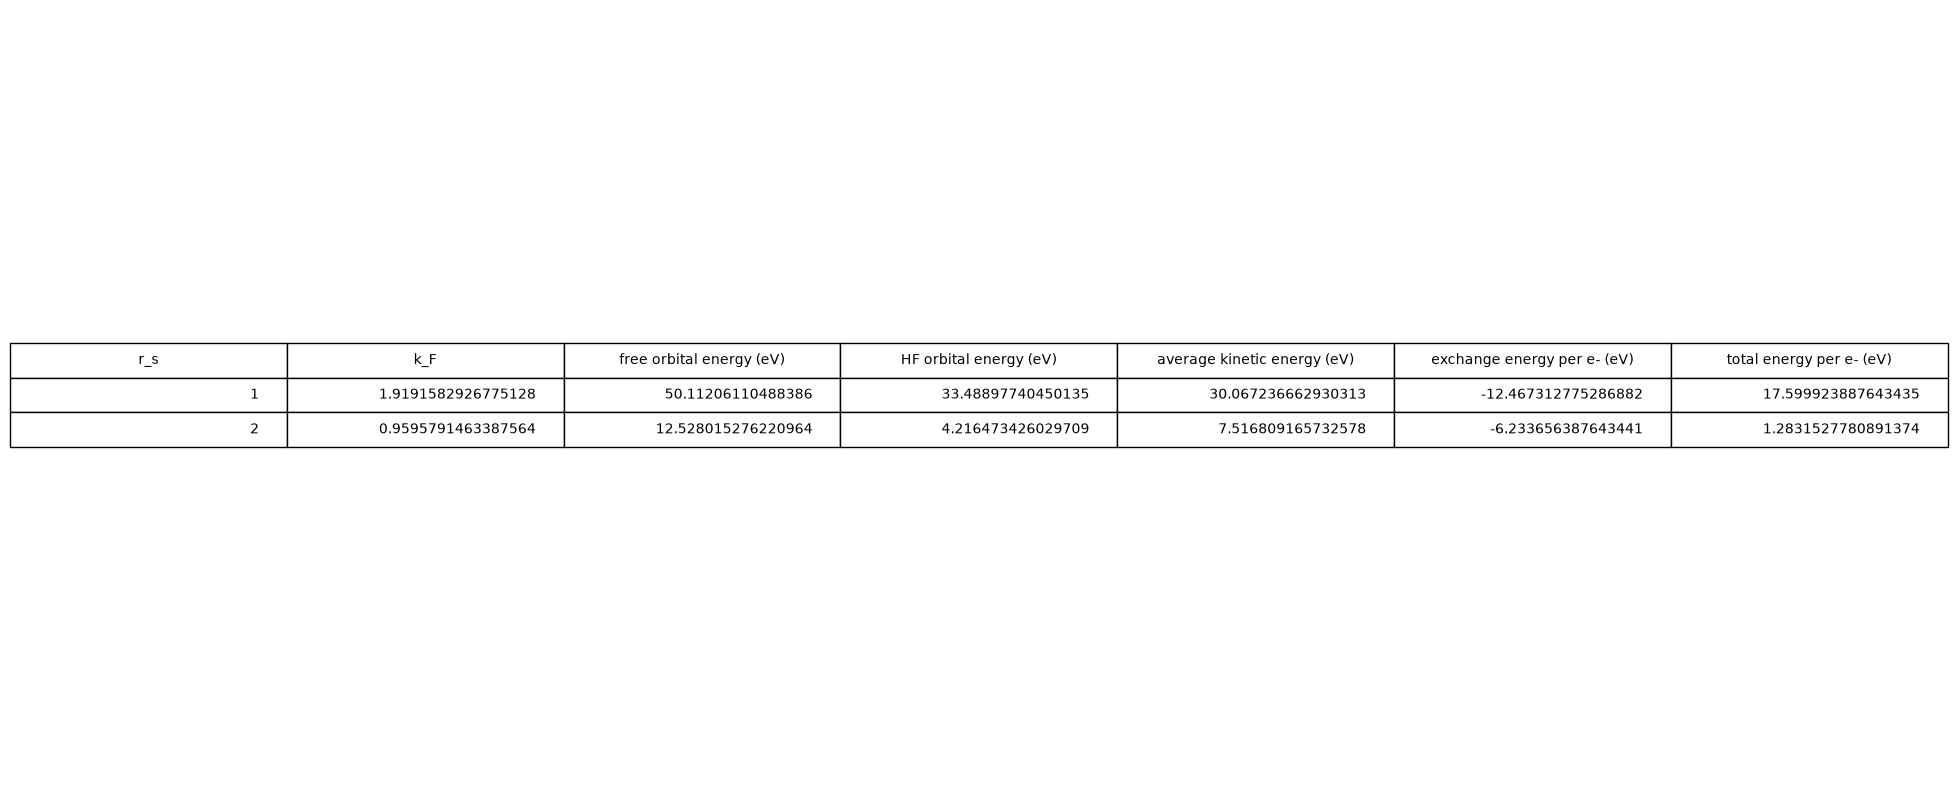

In [84]:
# task 3 

# for this table, we do need to convert from the hartree units to eV since the units are that hbar = m_e = e = 4 pi e_0 = 1. Outside of that, I just make functions for the kinetic and exchange energies to use in the table,
# and then loop through however many r_s we need, in this case 2. 

r_s_table = []

def avg_kin(r_s):
    return 0.3 * kF(r_s)**2

def exch_energy(r_s):
    return -(3 * kF(r_s))/(4 * np.pi)

e_charge = 	1.602176634 * 10**(-19)
permitivity = 8.8541878188 * 10**(-12)

ht_to_joule = (m_e * e_charge**4)/(4 * np.pi * permitivity * hbar)**2
ht_to_ev = ht_to_joule/e_charge

for i in range(1,3):
    r_s_table.append([i, kF(i), epsilon_free(1, i) * ht_to_ev, epsilon_HF(1, i) * ht_to_ev, avg_kin(i) * ht_to_ev, exch_energy(i) * ht_to_ev, (avg_kin(i) + exch_energy(i)) * ht_to_ev])

plt.table(cellText = r_s_table, colLabels = ["r_s", "k_F", "free orbital energy (eV)", "HF orbital energy (eV)", "average kinetic energy (eV)", "exchange energy per e- (eV)", "total energy per e- (eV)"], loc = "center")
plt.axis("off")
plt.gcf().set_size_inches(25,10)
plt.show()

Text(0, 0.5, 'energy (hartree units)')

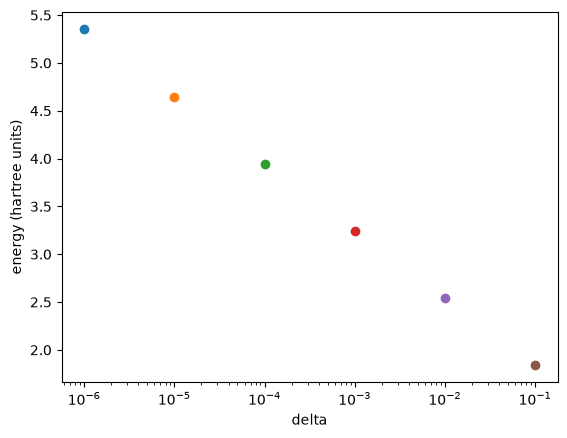

In [85]:
# task 4

# estimating with symmetric differences can be done with a loop for each delta, and then we can plot them for a visual comparison. Since the deltas are increasing by an order of magnitude, I set the x axis to a log scale.

for i in range(-6,0):
    plt.scatter(10**(i), (epsilon_HF(1 + 10**(i), 2) - epsilon_HF(1 - 10**(i), 2)) / (2 * 10**(i)))

plt.xscale("log")
plt.xlabel("delta")
plt.ylabel("energy (hartree units)")

# there is a clear upward trend as we approach delta = 0 and the derivative of fermi energy shoots off toward infinity. According to the textbook, this means there is an "unphysical vanishing density of states at the Fermi energy".

In [86]:
# task 5 

# HF uses a Slater determinant, which just vanishes if two electrons are in the same spin orbital. The exchange operator itself is nonlocal because the value at r depends on the orbital phi_i at all r'. Because the system is
# translationally invariant, plane waves are going to diagonalize the exchange operator, so they are the eigenfunctions.